Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.71MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.57MB/s]



========== Experiment 1 : Adam ==========

Epoch [1/10]
Train Loss: 0.2851 | Train Accuracy: 90.96%
Validation Loss: 0.0652 | Validation Accuracy: 98.04%
-----------------------------------
Epoch [2/10]
Train Loss: 0.0962 | Train Accuracy: 97.13%
Validation Loss: 0.0506 | Validation Accuracy: 98.54%
-----------------------------------
Epoch [3/10]
Train Loss: 0.0747 | Train Accuracy: 97.88%
Validation Loss: 0.0496 | Validation Accuracy: 98.47%
-----------------------------------
Epoch [4/10]
Train Loss: 0.0601 | Train Accuracy: 98.23%
Validation Loss: 0.0379 | Validation Accuracy: 98.93%
-----------------------------------
Epoch [5/10]
Train Loss: 0.0506 | Train Accuracy: 98.50%
Validation Loss: 0.0410 | Validation Accuracy: 98.78%
-----------------------------------
Epoch [6/10]
Train Loss: 0.0417 | Train Accuracy: 98.70%
Validation Loss: 0.0342 | Validation Accuracy: 98.99%
-----------------------------------
Epoch [7/10]
Train Loss: 0.0363 | Train Accuracy: 98.85%
Validation Loss: 

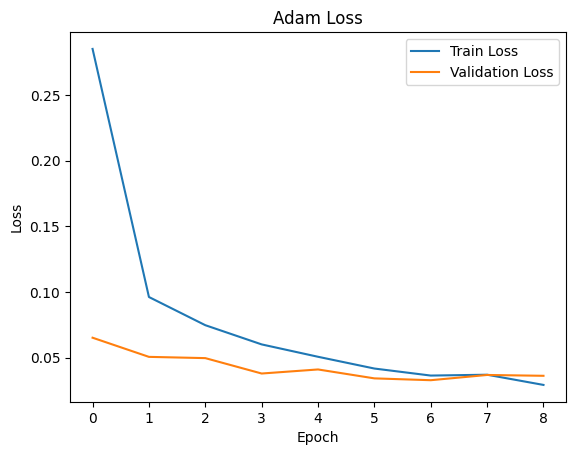

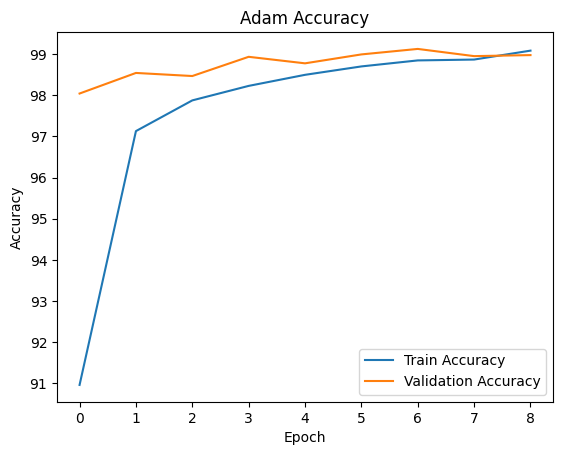

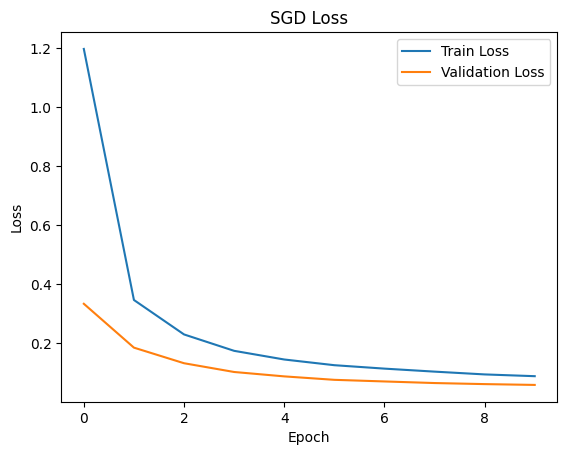

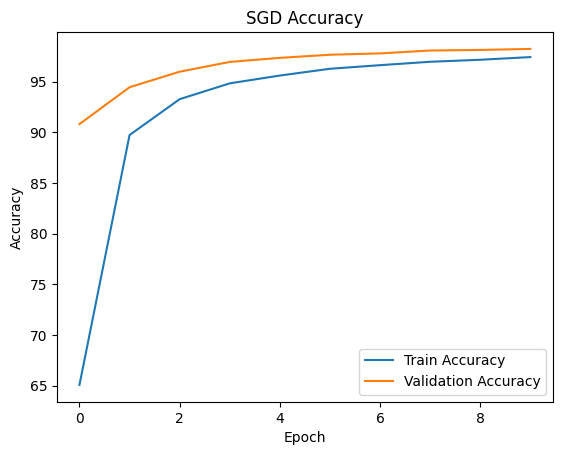


Final Comparison Results
Model                Accuracy        Loss
CNN + Adam           99.27%           0.0286
CNN + SGD            98.38%           0.0476


In [1]:
# ============================================
# Import Libraries
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

# ============================================
# Check Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ============================================
# Data Preprocessing
# ============================================

transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

# ============================================
# Load MNIST Dataset
# ============================================

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# ============================================
# Split Train and Validation
# ============================================

train_size = int(0.8 * len(full_train_dataset))

val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

# ============================================
# DataLoader
# ============================================

batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# ============================================
# CNN Model
# ============================================

class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

# ============================================
# Training Function
# ============================================

def train_model(model, optimizer, epochs=10):

    criterion = nn.CrossEntropyLoss()

    train_losses = []

    train_accuracies = []

    val_losses = []

    val_accuracies = []

    # ========================================
    # Early Stopping Variables
    # ========================================

    best_val_loss = float('inf')

    patience = 2

    counter = 0

    for epoch in range(epochs):

        # ====================================
        # Training
        # ====================================

        model.train()

        running_loss = 0

        correct = 0

        total = 0

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)

        epoch_accuracy = 100 * correct / total

        train_losses.append(epoch_loss)

        train_accuracies.append(epoch_accuracy)

        # ====================================
        # Validation
        # ====================================

        model.eval()

        val_loss = 0

        val_correct = 0

        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)

                val_total += labels.size(0)

                val_correct += (predicted == labels).sum().item()

        final_val_loss = val_loss / len(val_loader)

        final_val_accuracy = 100 * val_correct / val_total

        val_losses.append(final_val_loss)

        val_accuracies.append(final_val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")

        print(f"Train Loss: {epoch_loss:.4f} | "
              f"Train Accuracy: {epoch_accuracy:.2f}%")

        print(f"Validation Loss: {final_val_loss:.4f} | "
              f"Validation Accuracy: {final_val_accuracy:.2f}%")

        print("-----------------------------------")

        # ====================================
        # Early Stopping
        # ====================================

        if final_val_loss < best_val_loss:

            best_val_loss = final_val_loss

            counter = 0

        else:

            counter += 1

        if counter >= patience:

            print("Early Stopping Activated")

            break

    return (
        train_losses,
        train_accuracies,
        val_losses,
        val_accuracies
    )

# ============================================
# Testing Function
# ============================================

def test_model(model):

    criterion = nn.CrossEntropyLoss()

    model.eval()

    test_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    final_loss = test_loss / len(test_loader)

    final_accuracy = 100 * correct / total

    return final_loss, final_accuracy

# ============================================
# Experiment 1
# CNN + Adam
# ============================================

print("\n========== Experiment 1 : Adam ==========\n")

model_adam = SimpleCNN().to(device)

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

(
    adam_train_losses,
    adam_train_accuracies,
    adam_val_losses,
    adam_val_accuracies
) = train_model(
    model_adam,
    optimizer_adam
)

adam_test_loss, adam_test_accuracy = test_model(model_adam)

print("\nAdam Test Accuracy:", adam_test_accuracy)

print("Adam Test Loss:", adam_test_loss)

# ============================================
# Experiment 2
# CNN + SGD
# ============================================

print("\n========== Experiment 2 : SGD ==========\n")

model_sgd = SimpleCNN().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01
)

(
    sgd_train_losses,
    sgd_train_accuracies,
    sgd_val_losses,
    sgd_val_accuracies
) = train_model(
    model_sgd,
    optimizer_sgd
)

sgd_test_loss, sgd_test_accuracy = test_model(model_sgd)

print("\nSGD Test Accuracy:", sgd_test_accuracy)

print("SGD Test Loss:", sgd_test_loss)

# ============================================
# Visualization
# Adam Loss Curve
# ============================================

plt.plot(adam_train_losses, label='Train Loss')

plt.plot(adam_val_losses, label='Validation Loss')

plt.title('Adam Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

# ============================================
# Visualization
# Adam Accuracy Curve
# ============================================

plt.plot(adam_train_accuracies, label='Train Accuracy')

plt.plot(adam_val_accuracies, label='Validation Accuracy')

plt.title('Adam Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

# ============================================
# Visualization
# SGD Loss Curve
# ============================================

plt.plot(sgd_train_losses, label='Train Loss')

plt.plot(sgd_val_losses, label='Validation Loss')

plt.title('SGD Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

# ============================================
# Visualization
# SGD Accuracy Curve
# ============================================

plt.plot(sgd_train_accuracies, label='Train Accuracy')

plt.plot(sgd_val_accuracies, label='Validation Accuracy')

plt.title('SGD Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

# ============================================
# Final Results Table
# ============================================

print("\n===================================")

print("Final Comparison Results")

print("===================================")

print(f"{'Model':<20} {'Accuracy':<15} {'Loss'}")

print(f"{'CNN + Adam':<20} "
      f"{adam_test_accuracy:.2f}%"
      f"{'':<10} "
      f"{adam_test_loss:.4f}")

print(f"{'CNN + SGD':<20} "
      f"{sgd_test_accuracy:.2f}%"
      f"{'':<10} "
      f"{sgd_test_loss:.4f}")